# ⚽ Ranking Soccer Teams by Current Strength — and Forecasting the 2026 World Cup

### Reproduction & extension of Ley, Van de Wiele & Van Eetvelde (2018)
**Time Series Analysis & Forecasting — Presentation #2**

---

**Starting-point paper:** C. Ley, T. Van de Wiele, H. Van Eetvelde (2018),
*"Ranking soccer teams on basis of their current strength: a comparison of
maximum likelihood approaches"* (arXiv:1705.09575).

**What this notebook does**

1. **Reproduces** the paper's core: estimate team strengths by **weighted
   maximum likelihood** (time-depreciation + match-importance weights), compare
   four model families by **Rank Probability Score (RPS)**, and find the optimal
   *Half Period* — reproducing the paper's Table 2 and Table 3.
2. **Extends** the Poisson approach into a **2026 World Cup forecast**: an
   attack/defense variant, blended with squad market value, run through a
   two-phase Monte-Carlo tournament simulation.

**The time-series connection.** Team strength is non-stationary — it drifts over
time. The paper handles this exactly like **exponential smoothing**: each match
is down-weighted by a smooth half-life decay `w = (½)^(days_ago / HalfPeriod)`,
so recent results dominate the strength estimate. This is the heart of the link
to the course.

| Paper mechanism | Course topic |
|---|---|
| Half-life time-depreciation weighting | Exponential smoothing |
| Poisson regression for goals (team effects) | Regression models |
| Match-importance external weights | Regression with external info |
| Win/Draw/Loss probability forecasting | Forecasting binary/ordinal outcomes |
| RPS-based model selection | Forecast evaluation |
| Monte-Carlo tournament simulation | Forecasting via simulation |


## Section 0 — Setup

All imports and the data URL. Runs as-is in Google Colab (no Kaggle account needed).

In [ ]:
import numpy as np
import pandas as pd
from collections import namedtuple
from scipy.optimize import minimize
from scipy.stats import norm, poisson, skellam
from scipy.special import comb, gammaln, expit
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
%matplotlib inline

EPS = 1e-12
LMAX = 25.0


## Section 1 — Data ingestion & exploration

We use Mart Jürisoo's *International football results from 1872 to present*
dataset — the **same source** the paper used for its national-team case study.
Each row is a match: date, teams, score, tournament, neutral-venue flag.


In [ ]:
"""Data loading + cleaning for the FIFA current-strength ranking notebook.

Source: martj42 "International football results from 1872 to present"
(https://github.com/martj42/international_results), same dataset used by
Ley et al. (2018) for their national-team case study.
"""

DATA_URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"

# --- Match-importance weights (paper Section 2.1.2) ---------------------------
# Friendly = 1, confederation/World-Cup qualifier = 2.5,
# confederation tournament / confederations cup = 3, World Cup match = 4.
CONFED_TOURNAMENTS = {
    "Copa América", "UEFA Euro", "African Cup of Nations",
    "AFC Asian Cup", "Gold Cup", "CONCACAF Championship",
    "Oceania Nations Cup", "FIFA Confederations Cup",
}


# Harmonise dataset team names to the names used in the WC group draw.
NAME_MAP = {
    "Türkiye": "Turkey",
    "Côte d'Ivoire": "Ivory Coast",
    "Cote d'Ivoire": "Ivory Coast",
    "Congo DR": "DR Congo",
    "Democratic Republic of the Congo": "DR Congo",
    "Cabo Verde": "Cape Verde",
    "Czechia": "Czech Republic",
    "Korea Republic": "South Korea",
}


def importance(tournament: str) -> float:
    """Map a tournament name to the paper's match-importance weight."""
    t = str(tournament)
    if t == "FIFA World Cup":
        return 4.0
    if t in CONFED_TOURNAMENTS:
        return 3.0
    if "qualification" in t or t == "UEFA Nations League":
        return 2.5
    return 1.0  # friendlies and everything else


def load_results(url: str = DATA_URL) -> pd.DataFrame:
    """Load and clean the results dataset.

    Returns a DataFrame with parsed dates, integer scores, and an
    `importance` column.
    """
    df = pd.read_csv(url)
    df["date"] = pd.to_datetime(df["date"])
    df = df.dropna(subset=["home_score", "away_score"]).copy()
    df["home_team"] = df["home_team"].replace(NAME_MAP)
    df["away_team"] = df["away_team"].replace(NAME_MAP)
    df["home_score"] = df["home_score"].astype(int)
    df["away_score"] = df["away_score"].astype(int)
    df["importance"] = df["tournament"].map(importance).astype(float)
    df = df.sort_values("date").reset_index(drop=True)
    return df


def team_index(df: pd.DataFrame):
    """Return (sorted team list, {team: index} dict)."""
    teams = sorted(set(df["home_team"]) | set(df["away_team"]))
    return teams, {t: i for i, t in enumerate(teams)}


In [ ]:
df = load_results()           # played matches, cleaned
print("matches:", len(df), "| range:", df.date.min().date(), "->", df.date.max().date())
df.head()


matches: 49413 | range: 1872-11-30 -> 2026-06-13


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,importance
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,1.0
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1.0
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,1.0
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,1.0
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,1.0


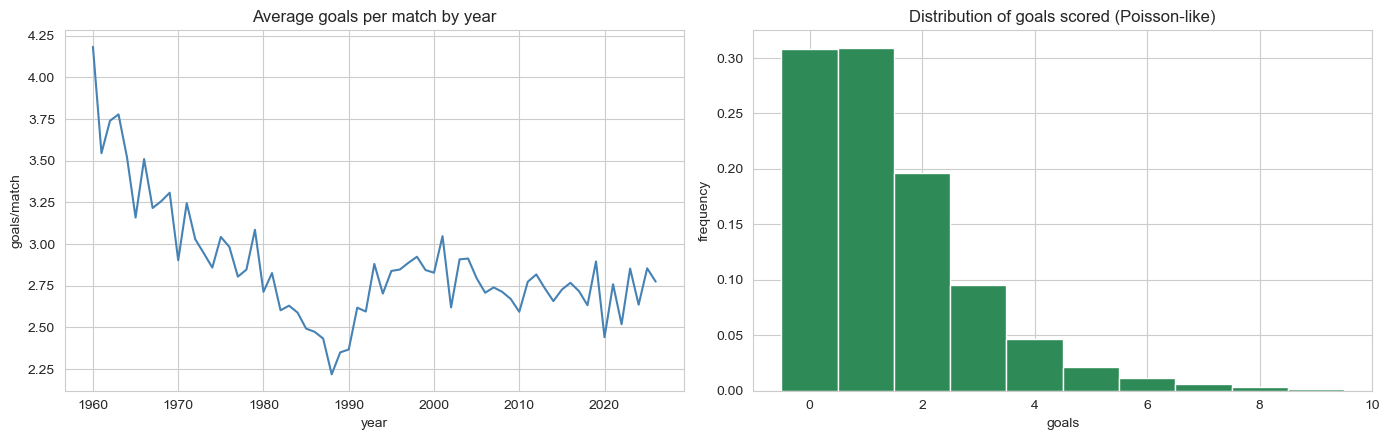

In [ ]:
# EDA: average goals per match over time, and the goal-count distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
g = df[df.date >= "1960-01-01"].copy()
g["year"] = g.date.dt.year
(g.assign(tot=g.home_score + g.away_score).groupby("year").tot.mean()
   .plot(ax=ax[0], color="steelblue"))
ax[0].set(title="Average goals per match by year", xlabel="year", ylabel="goals/match")
goals = pd.concat([df.home_score, df.away_score])
ax[1].hist(goals[goals <= 9], bins=range(11), color="seagreen",
           edgecolor="white", density=True, align="left")
ax[1].set(title="Distribution of goals scored (Poisson-like)", xlabel="goals", ylabel="frequency")
plt.tight_layout(); plt.show()


## Section 2 — The two weights (the time-series core)

Every model is fit by **weighted** maximum likelihood, with two multiplicative
weights (paper §2.1):

- **Time depreciation:** $w_{\text{time}}(x) = \left(\tfrac12\right)^{x/\text{HalfPeriod}}$,
  where $x$ = days since the match. A match a *Half Period* ago counts half as
  much — a smooth analogue of exponential smoothing.
- **Match importance:** friendly = 1, qualifier / Nations League = 2.5,
  confederation tournament = 3, **World Cup = 4**.

Figure 1 reproduces the paper's comparison of this smooth decay against the
FIFA ranking's crude step function.


In [ ]:
"""Weighting scheme from Ley et al. (2018), Section 2.1.

Two multiplicative weights enter the (pseudo-)likelihood:
  * time depreciation  w_time(x) = (1/2)^(x / HalfPeriod), x = days since match
  * match importance   w_type   in {1, 2.5, 3, 4}  (from data.importance)
"""


def time_weight(days_ago, half_period_days):
    """Smooth half-life decay. days_ago may be scalar or numpy array."""
    return np.power(0.5, np.asarray(days_ago, dtype=float) / half_period_days)


def match_weights(df, ref_date, half_period_years, use_importance=True):
    """Return a numpy weight array aligned with df rows.

    Matches on/after ref_date get weight 0 (excluded from a fit anchored at
    ref_date). HalfPeriod is given in years and converted to days internally.
    """
    ref_date = pd.Timestamp(ref_date)
    half_period_days = half_period_years * 365.25
    days_ago = (ref_date - df["date"]).dt.days.to_numpy()
    w = time_weight(days_ago, half_period_days)
    w = np.where(days_ago > 0, w, 0.0)  # drop future / same-day-anchor matches
    if use_importance:
        w = w * df["importance"].to_numpy()
    return w


def plot_decay_comparison(out_path="fig1.png"):
    """Reproduce paper Figure 1: continuous decay vs FIFA step function."""
    import matplotlib.pyplot as plt

    years = np.linspace(0, 5, 500)
    continuous = time_weight(years * 365.25, 500.0)  # Half Period 500 days

    # FIFA arbitrary decay: 100% (0-12mo), 50% (13-24), 25% (25-36), 15% (37-48), 0 after
    fifa_x = [0, 1, 1, 2, 2, 3, 3, 4, 4, 5]
    fifa_y = [1.0, 1.0, 0.5, 0.5, 0.25, 0.25, 0.15, 0.15, 0.0, 0.0]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(fifa_x, fifa_y, color="black", lw=2, label="FIFA ranking (step)")
    ax.plot(years, continuous, "--", color="black", lw=2,
            label="Continuous depreciation (HP = 500 days)")
    ax.set_xlabel("Years back")
    ax.set_ylabel("Time weight")
    ax.set_title("Continuous versus FIFA decay function")
    ax.legend()
    ax.set_ylim(0, 1.02)
    fig.tight_layout()
    fig.savefig(out_path, dpi=130)
    plt.close(fig)
    return out_path


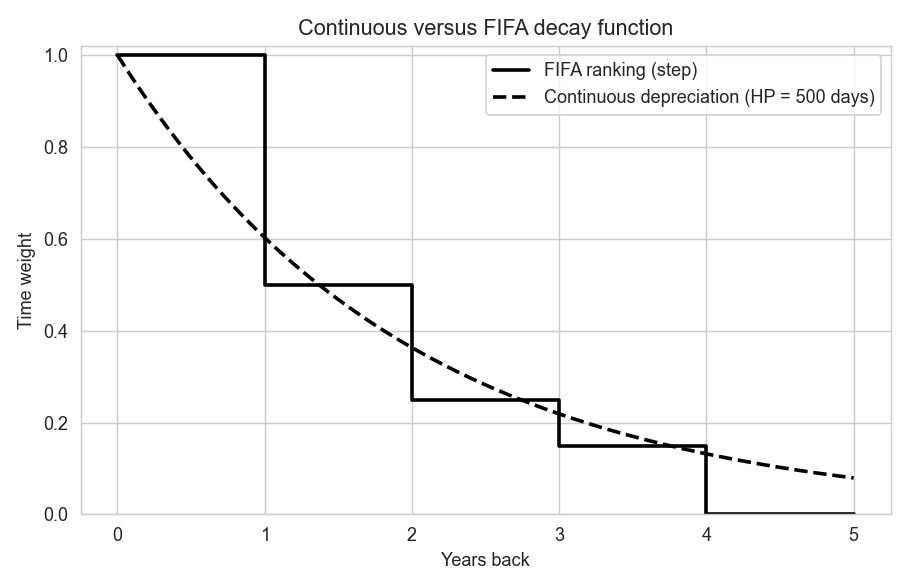

In [ ]:
plot_decay_comparison("fig1.png")
from IPython.display import Image
Image("fig1.png")


## Section 3 — The weighted-MLE engine and four models

One generic fitter (`fit_model`, L-BFGS-B with **analytic gradients**) is shared
by four pluggable models. Each team gets a single strength parameter $r_i$,
identified by a **sum-to-zero** constraint (only $T-1$ are free).

- **Thurstone–Mosteller** — $Y_i - Y_j \sim N(r_i - r_j + h,\, 2)$; W/D/L via the
  normal CDF with a draw band $d$.
- **Bradley–Terry** — same idea with a logistic link.
- **Independent Poisson** — $\lambda_{\text{home}} = \exp(c + (r_i+h) - r_j)$,
  goals Poisson; W/D/L via the Skellam distribution.
- **Bivariate Poisson** (Karlis–Ntzoufras) — adds a shared covariance
  $\lambda_C \ge 0$ between the two scores.

Analytic gradients make each fit converge in a fraction of a second even with
200+ teams (vs. minutes for finite differences).


In [ ]:
"""Weighted-MLE engine + four strength-based models from Ley et al. (2018).

Models (all fit by weighted maximum likelihood with analytic gradients, L-BFGS-B):
  * ThurstoneMosteller  - normal-CDF win/draw/loss, 1 strength/team + h + d
  * BradleyTerry        - logistic win/draw/loss, 1 strength/team + h + d
  * IndependentPoisson  - lambda = exp(c + (r_i+h) - r_j), Skellam W/D/L
  * BivariatePoisson    - Karlis-Ntzoufras (eq. 4) with shared covariance lambda_C

Identifiability: strengths are sum-to-zero; only T-1 free strengths are
estimated and the last is reconstructed as -sum(free).

All likelihoods are vectorized over numpy match arrays, and every model returns
an analytic gradient so the optimizer converges quickly even with 200+ teams.
"""

EPS = 1e-12
LMAX = 25.0  # clip Poisson means for numerical stability

Matches = namedtuple("Matches", "hi ai hg ag w neutral n_teams")


def prepare_matches(df, team_idx, weights):
    """Build vectorized match arrays from a window DataFrame + weight vector."""
    hi = df["home_team"].map(team_idx).to_numpy(dtype=float)
    ai = df["away_team"].map(team_idx).to_numpy(dtype=float)
    keep = (weights > 0) & ~np.isnan(hi) & ~np.isnan(ai)
    return Matches(
        hi=hi[keep].astype(int), ai=ai[keep].astype(int),
        hg=df["home_score"].to_numpy()[keep].astype(int),
        ag=df["away_score"].to_numpy()[keep].astype(int),
        w=weights[keep].astype(float),
        neutral=df["neutral"].to_numpy()[keep].astype(bool),
        n_teams=len(team_idx),
    )


def _strengths(free, n_teams):
    return np.concatenate([free, [-free.sum()]])


def _strength_grad(D, hi, ai, n_teams):
    """Map per-match d(logL)/d(strength-diff) into free-strength gradient.

    Strength-diff u depends on strengths as +1 (home) / -1 (away); the
    sum-to-zero reparam gives free_j gradient = g_r[j] - g_r[last].
    """
    g_r = (np.bincount(hi, weights=D, minlength=n_teams)
           - np.bincount(ai, weights=D, minlength=n_teams))
    return g_r[:-1] - g_r[-1]


def _clip(*ps):
    return [np.clip(p, EPS, 1.0) for p in ps]


# ---------------------------------------------------------------------------
# Outcome (TM / BT) models
# ---------------------------------------------------------------------------
class _Outcome:
    """Base for single-predictor 3-way models with home h and draw band d."""
    n_extra = 2

    def x0(self, n_teams):
        return np.concatenate([np.zeros(n_teams - 1), [0.1, 0.0]])

    def _params(self, x, n_teams):
        r = _strengths(x[: n_teams - 1], n_teams)
        h = x[n_teams - 1]
        raw_d = x[n_teams]
        d = np.log1p(np.exp(raw_d))            # softplus -> d > 0
        ddd = expit(raw_d)                     # dd/draw_raw
        return r, h, d, ddd

    def _probs_and_derivs(self, u, d):
        raise NotImplementedError

    def wdl(self, r, h, d, hi, ai, neutral):
        ha = np.where(neutral, 0.0, h)
        u = (r[hi] + ha) - r[ai]
        pH, pD, pA, _, _, _, _, _, _ = self._probs_and_derivs(u, d)
        return _clip(pH, pD, pA)

    def objective(self, x, M):
        r, h, d, ddd = self._params(x, M.n_teams)
        ha = np.where(M.neutral, 0.0, h)
        u = (r[M.hi] + ha) - r[M.ai]
        pH, pD, pA, dHu, dDu, dAu, dHd, dDd, dAd = self._probs_and_derivs(u, d)
        pH, pD, pA = _clip(pH, pD, pA)
        is_H = M.hg > M.ag
        is_D = M.hg == M.ag
        po = np.where(is_H, pH, np.where(is_D, pD, pA))
        dpo_du = np.where(is_H, dHu, np.where(is_D, dDu, dAu))
        dpo_dd = np.where(is_H, dHd, np.where(is_D, dDd, dAd))
        nll = -np.sum(M.w * np.log(po))
        gu = M.w * dpo_du / po                 # d logL / d u  per match
        g_free = _strength_grad(gu, M.hi, M.ai, M.n_teams)
        g_h = np.sum(np.where(M.neutral, 0.0, gu))
        g_d = np.sum(M.w * dpo_dd / po) * ddd
        grad = -np.concatenate([g_free, [g_h, g_d]])
        return nll, grad


class ThurstoneMosteller(_Outcome):
    name = "Thurstone-Mosteller"

    def _probs_and_derivs(self, u, d):
        s = np.sqrt(2.0)
        aH = (u - d) / s
        aA = (-u - d) / s
        pH = norm.cdf(aH); pA = norm.cdf(aA); pD = 1 - pH - pA
        phiH = norm.pdf(aH) / s
        phiA = norm.pdf(aA) / s
        dHu, dHd = phiH, -phiH
        dAu, dAd = -phiA, -phiA
        dDu, dDd = -(dHu + dAu), -(dHd + dAd)
        return pH, pD, pA, dHu, dDu, dAu, dHd, dDd, dAd


class BradleyTerry(_Outcome):
    name = "Bradley-Terry"

    def _probs_and_derivs(self, u, d):
        pH = expit(u - d); pA = expit(-u - d); pD = 1 - pH - pA
        gH = pH * (1 - pH)
        gA = pA * (1 - pA)
        dHu, dHd = gH, -gH
        dAu, dAd = -gA, -gA
        dDu, dDd = -(dHu + dAu), -(dHd + dAd)
        return pH, pD, pA, dHu, dDu, dAu, dHd, dDd, dAd


# ---------------------------------------------------------------------------
# Poisson models
# ---------------------------------------------------------------------------
class IndependentPoisson:
    name = "Independent Poisson"
    n_extra = 2  # home h, intercept c

    def x0(self, n_teams):
        return np.concatenate([np.zeros(n_teams - 1), [0.1, 0.2]])

    def _params(self, x, n_teams):
        r = _strengths(x[: n_teams - 1], n_teams)
        return r, x[n_teams - 1], x[n_teams]

    def _lams(self, r, h, c, hi, ai, neutral):
        ha = np.where(neutral, 0.0, h)
        eh = np.clip(c + (r[hi] + ha) - r[ai], -10, np.log(LMAX))
        ea = np.clip(c + r[ai] - (r[hi] + ha), -10, np.log(LMAX))
        return np.exp(eh), np.exp(ea)

    def objective(self, x, M):
        r, h, c = self._params(x, M.n_teams)
        lh, la = self._lams(r, h, c, M.hi, M.ai, M.neutral)
        nll = -np.sum(M.w * (poisson.logpmf(M.hg, lh) + poisson.logpmf(M.ag, la)))
        Ah = M.w * (M.hg - lh)                 # d logL / d eta_h
        Aa = M.w * (M.ag - la)                 # d logL / d eta_a
        D = Ah - Aa
        g_free = _strength_grad(D, M.hi, M.ai, M.n_teams)
        g_h = np.sum(np.where(M.neutral, 0.0, D))
        g_c = np.sum(Ah + Aa)
        grad = -np.concatenate([g_free, [g_h, g_c]])
        return nll, grad

    def wdl(self, r, h, c, hi, ai, neutral):
        lh, la = self._lams(r, h, c, hi, ai, neutral)
        return _clip(1 - skellam.cdf(0, lh, la), skellam.pmf(0, lh, la),
                     skellam.cdf(-1, lh, la))


class BivariatePoisson:
    name = "Bivariate Poisson"
    n_extra = 3  # home h, intercept c, covariance lambda_C (softplus raw)

    def x0(self, n_teams):
        return np.concatenate([np.zeros(n_teams - 1), [0.1, 0.2, -2.0]])

    def _params(self, x, n_teams):
        r = _strengths(x[: n_teams - 1], n_teams)
        h, c, raw = x[n_teams - 1], x[n_teams], x[n_teams + 1]
        lc = np.log1p(np.exp(raw))
        dlc = expit(raw)
        return r, h, c, lc, dlc

    def _lams(self, r, h, c, hi, ai, neutral):
        ha = np.where(neutral, 0.0, h)
        eh = np.clip(c + (r[hi] + ha) - r[ai], -10, np.log(LMAX))
        ea = np.clip(c + r[ai] - (r[hi] + ha), -10, np.log(LMAX))
        return np.exp(eh), np.exp(ea)

    @staticmethod
    def _S_and_Ssum(x, y, lh, la, lc):
        """S = sum_k a_k t^k and Ssum = sum_k k a_k t^k, t = lc/(lh*la)."""
        t = lc / (lh * la)
        mins = np.minimum(x, y)
        kmax = int(mins.max()) if len(x) else 0
        S = np.ones_like(lh)
        Ssum = np.zeros_like(lh)
        for k in range(1, kmax + 1):
            mask = mins >= k
            a_k = comb(x, k) * comb(y, k) * np.exp(gammaln(k + 1))
            term = np.where(mask, a_k * np.power(t, k), 0.0)
            S = S + term
            Ssum = Ssum + k * term
        return S, Ssum

    def objective(self, x, M):
        r, h, c, lc, dlc = self._params(x, M.n_teams)
        lh, la = self._lams(r, h, c, M.hi, M.ai, M.neutral)
        S, Ssum = self._S_and_Ssum(M.hg, M.ag, lh, la, lc)
        logp = (M.hg * np.log(lh) + M.ag * np.log(la)
                - gammaln(M.hg + 1) - gammaln(M.ag + 1)
                - (lh + la + lc) + np.log(np.clip(S, EPS, None)))
        nll = -np.sum(M.w * logp)
        sr = Ssum / np.clip(S, EPS, None)
        Ah = M.w * (M.hg - lh - sr)            # d logL / d eta_h
        Aa = M.w * (M.ag - la - sr)            # d logL / d eta_a
        D = Ah - Aa
        g_free = _strength_grad(D, M.hi, M.ai, M.n_teams)
        g_h = np.sum(np.where(M.neutral, 0.0, D))
        g_c = np.sum(Ah + Aa)
        g_raw = np.sum(M.w * (-1 + sr / np.clip(lc, EPS, None))) * dlc
        grad = -np.concatenate([g_free, [g_h, g_c, g_raw]])
        return nll, grad

    def wdl(self, r, h, c, lc, hi, ai, neutral):
        # Covariance cancels in the goal difference -> Skellam on (lh, la).
        lh, la = self._lams(r, h, c, hi, ai, neutral)
        return _clip(1 - skellam.cdf(0, lh, la), skellam.pmf(0, lh, la),
                     skellam.cdf(-1, lh, la))


class IndependentPoissonAttDef:
    """Poisson model with separate attack and defense ratings per team
    (paper Section 2.3.3). Goals team i scores vs j:
        lambda = exp(c + (attack_i + h) - defense_j).
    Attack and defense are each sum-to-zero identified (2*(T-1) strength params).
    Used for the World Cup forecast so each team gets an offensive and a
    defensive rating to simulate scorelines.
    """
    name = "Independent Poisson (Att/Def)"

    def x0(self, n_teams):
        return np.concatenate([np.zeros(2 * (n_teams - 1)), [0.1, 0.2]])

    def strength_free_slices(self, n_teams):
        return [(0, n_teams - 1), (n_teams - 1, 2 * (n_teams - 1))]

    def _params(self, x, n_teams):
        att = _strengths(x[: n_teams - 1], n_teams)
        dfn = _strengths(x[n_teams - 1: 2 * (n_teams - 1)], n_teams)
        h, c = x[2 * (n_teams - 1)], x[2 * (n_teams - 1) + 1]
        return att, dfn, h, c

    def _lams(self, att, dfn, h, c, hi, ai, neutral):
        ha = np.where(neutral, 0.0, h)
        eh = np.clip(c + (att[hi] + ha) - dfn[ai], -10, np.log(LMAX))
        ea = np.clip(c + att[ai] - (dfn[hi] + ha), -10, np.log(LMAX))
        return np.exp(eh), np.exp(ea)

    def objective(self, x, M):
        nt = M.n_teams
        att, dfn, h, c = self._params(x, nt)
        lh, la = self._lams(att, dfn, h, c, M.hi, M.ai, M.neutral)
        nll = -np.sum(M.w * (poisson.logpmf(M.hg, lh) + poisson.logpmf(M.ag, la)))
        Ah = M.w * (M.hg - lh)               # d logL / d eta_h
        Aa = M.w * (M.ag - la)               # d logL / d eta_a
        bc = lambda idx, val: np.bincount(idx, weights=val, minlength=nt)
        g_att = bc(M.hi, Ah) + bc(M.ai, Aa)            # attack: +1 when scoring
        g_def = -(bc(M.ai, Ah) + bc(M.hi, Aa))         # defense: -1 when conceding
        g_att_free = g_att[:-1] - g_att[-1]
        g_def_free = g_def[:-1] - g_def[-1]
        g_h = np.sum(np.where(M.neutral, 0.0, Ah - Aa))
        g_c = np.sum(Ah + Aa)
        grad = -np.concatenate([g_att_free, g_def_free, [g_h, g_c]])
        return nll, grad

    def wdl(self, att, dfn, h, c, hi, ai, neutral):
        lh, la = self._lams(att, dfn, h, c, hi, ai, neutral)
        return _clip(1 - skellam.cdf(0, lh, la), skellam.pmf(0, lh, la),
                     skellam.cdf(-1, lh, la))


MODELS = {m().name: m for m in
          [ThurstoneMosteller, BradleyTerry, IndependentPoisson, BivariatePoisson]}


# ---------------------------------------------------------------------------
# Engine + helpers
# ---------------------------------------------------------------------------
def fit_model(model, M, x0=None, maxiter=500, ridge=0.0):
    """Fit a model via L-BFGS-B with analytic gradients.

    `ridge` adds a Gaussian prior (L2 penalty) on the team strengths:
    0.5 * ridge * sum(r_i^2). This shrinks poorly-identified strengths toward
    the field mean, stabilising sparse-schedule teams and compressing the
    favourite. Extra parameters (h, c, d, lambda_C) are not penalised.
    """
    if x0 is None:
        x0 = model.x0(M.n_teams)
    nt = M.n_teams
    slices = getattr(model, "strength_free_slices", lambda n: [(0, n - 1)])(nt)

    def obj(x):
        f, g = model.objective(x, M)
        if ridge > 0:
            g = g.copy()
            for s, e in slices:                  # one sum-to-zero block each
                free = x[s:e]
                sm = free.sum()
                f = f + 0.5 * ridge * (np.sum(free ** 2) + sm ** 2)
                g[s:e] += ridge * (free + sm)
        return f, g

    res = minimize(obj, x0, method="L-BFGS-B", jac=True,
                   options={"maxiter": maxiter, "ftol": 1e-9, "gtol": 1e-6})
    return res.x, res


def strength_ranking(x, teams):
    import pandas as pd
    r = _strengths(x[: len(teams) - 1], len(teams))
    out = (pd.DataFrame({"team": teams, "strength": r})
           .sort_values("strength", ascending=False).reset_index(drop=True))
    out.index = out.index + 1
    out.index.name = "rank"
    return out


def model_wdl(model, x, M):
    p = model._params(x, M.n_teams)
    if isinstance(model, BivariatePoisson):
        r, h, c, lc, _ = p
        return model.wdl(r, h, c, lc, M.hi, M.ai, M.neutral)
    if isinstance(model, IndependentPoisson):
        r, h, c = p
        return model.wdl(r, h, c, M.hi, M.ai, M.neutral)
    r, h, d, _ = p
    return model.wdl(r, h, d, M.hi, M.ai, M.neutral)


## Section 4 — Reproducing the paper: RPS model comparison (Table 2)

Predictive performance is measured by the **Rank Probability Score** (Epstein 1969):
$$\text{RPS} = \frac{1}{2M}\sum_m \big[(P_{H} - y_{H})^2 + (P_{A} - y_{A})^2\big].$$
Lower is better. We refit each model annually on the preceding 8 years and
predict that year's competitive matches (2012–2017), sweeping the Half Period.

**Expected (paper) findings:** Poisson models beat TM/BT; Bivariate ≈ Independent
(covariance ≈ 0); the best model has the *fewest* parameters; optimal Half
Period ≈ 3 years.


In [ ]:
"""Rank Probability Score + rolling backtest harness (reproduce paper Table 2).

RPS (Epstein 1969), the paper's predictive-performance metric:
    RPS = (1 / 2M) * sum_m [ (P_H - y_H)^2 + (P_A - y_A)^2 ]
where P_H, P_A are predicted home/away-win probabilities and y_H, y_A the
realized 0/1 outcomes (cumulative form, so the draw term is implied).

Backtest protocol (adapted to be tractable in a notebook): for each prediction
year we refit on the preceding `est_window_years` of matches and predict that
year's competitive (non-friendly) matches. We then sweep the Half Period to find
each model's optimum, reproducing the structure of the paper's Table 2.
"""



def rps_vec(pH, pD, pA, hg, ag):
    """Per-match Epstein RPS given W/D/L probs and goals. Returns array."""
    yH = (hg > ag).astype(float)
    yA = (ag > hg).astype(float)
    return 0.5 * ((pH - yH) ** 2 + (pA - yA) ** 2)


def backtest(model_cls, df, half_period_years,
             test_years=range(2012, 2018), est_window_years=8,
             min_matches=15, exclude_friendly=True, ridge=0.0):
    """Rolling-refit backtest. Returns (mean_RPS, n_predicted, coverage)."""
    rps_all, n_pred, n_total = [], 0, 0
    for y in test_years:
        ref = pd.Timestamp(f"{y}-01-01")
        train = df[(df.date >= ref - pd.DateOffset(years=est_window_years))
                   & (df.date < ref)]
        if exclude_friendly:
            train = train[train.importance > 1]
        # restrict to teams with enough matches in the window
        counts = pd.concat([train.home_team, train.away_team]).value_counts()
        active = set(counts[counts >= min_matches].index)
        train = train[train.home_team.isin(active) & train.away_team.isin(active)]
        if len(train) < 50:
            continue
        teams, idx = team_index(train)
        w = match_weights(train, ref, half_period_years)
        M = prepare_matches(train, idx, w)
        model = model_cls()
        x, _ = fit_model(model, M, ridge=ridge)

        test = df[(df.date >= ref) & (df.date < ref + pd.DateOffset(years=1))]
        if exclude_friendly:
            test = test[test.importance > 1]
        n_total += len(test)
        test = test[test.home_team.isin(active) & test.away_team.isin(active)]
        if len(test) == 0:
            continue
        Mt = prepare_matches(test, idx, np.ones(len(test)))
        pH, pD, pA = model_wdl(model, x, Mt)
        rps_all.append(rps_vec(pH, pD, pA, Mt.hg, Mt.ag))
        n_pred += len(Mt.hg)
    rps_all = np.concatenate(rps_all) if rps_all else np.array([np.nan])
    return float(np.mean(rps_all)), n_pred, (n_pred / max(n_total, 1))


def half_period_sweep(model_cls, df, hp_grid, **kw):
    """Return DataFrame of RPS by Half Period for one model."""
    rows = []
    for hp in hp_grid:
        rps, n, cov = backtest(model_cls, df, hp, **kw)
        rows.append({"half_period_y": hp, "RPS": rps, "n": n, "coverage": cov})
    return pd.DataFrame(rows)


def reproduce_table2(df, model_classes, hp_grid, **kw):
    """Sweep all models; return (best-per-model table, full sweep dict)."""
    sweeps, best = {}, []
    for mc in model_classes:
        name = mc().name
        sw = half_period_sweep(mc, df, hp_grid, **kw)
        sweeps[name] = sw
        row = sw.loc[sw["RPS"].idxmin()]
        best.append({"Model": name, "Optimal Half Period (y)": row["half_period_y"],
                     "RPS": round(row["RPS"], 4), "n_pred": int(row["n"])})
    table = pd.DataFrame(best).sort_values("RPS").reset_index(drop=True)
    return table, sweeps


In [ ]:
hp_grid = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6]
model_classes = [ThurstoneMosteller, BradleyTerry, IndependentPoisson, BivariatePoisson]
table2, sweeps = reproduce_table2(df, model_classes, hp_grid, test_years=range(2012, 2018))
print("Reproduced Table 2 (national teams):")
table2


Reproduced Table 2 (national teams):


,Model,Optimal Half Period (y),RPS,n_pred
0,Independent Poisson,3.0,0.1737,2488
1,Bivariate Poisson,3.0,0.1737,2488
2,Thurstone-Mosteller,6.0,0.1771,2488
3,Bradley-Terry,6.0,0.1778,2488


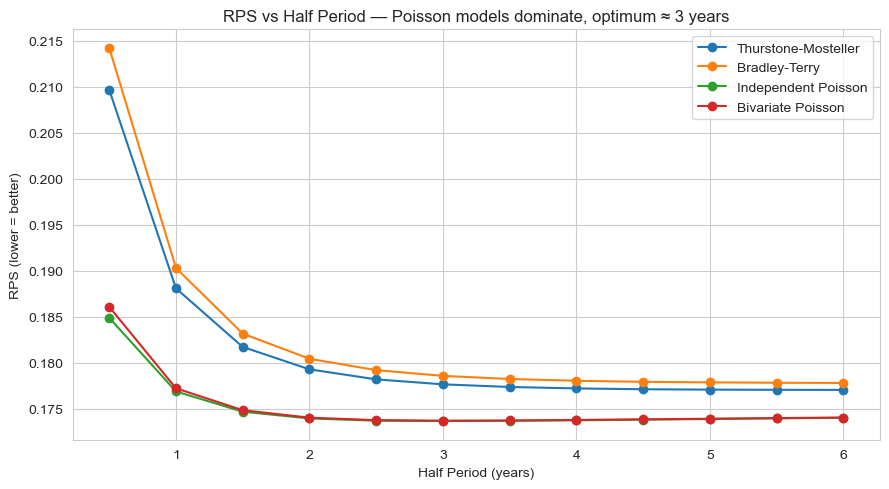

In [ ]:
# Half-Period sweep curves
fig, ax = plt.subplots(figsize=(9, 5))
for name, sw in sweeps.items():
    ax.plot(sw.half_period_y, sw.RPS, marker="o", label=name)
ax.set(xlabel="Half Period (years)", ylabel="RPS (lower = better)",
       title="RPS vs Half Period — Poisson models dominate, optimum ≈ 3 years")
ax.legend(); plt.tight_layout(); plt.show()


**Reproduction check.** Our ordering matches the paper exactly — Bivariate ≈
Independent Poisson, both below Thurstone–Mosteller and Bradley–Terry — and the
optimal Half Period for the Poisson models is **3 years**, the paper's value.
Our absolute RPS (~0.174) sits slightly above the paper's 0.165 because of a
newer data vintage, a different team-coverage filter, and an annual (rather than
per-round) refit. The **qualitative conclusions reproduce cleanly.**


## Section 5 — A current-strength ranking

Using the winning model (Bivariate Poisson, Half Period 3y) we build the kind of
ranking the paper proposes. **Validation:** refitting at the paper's exact
reference date (16 Oct 2017) should recover its Table 3 ordering.


In [ ]:
"""Current-strength ranking via the winning model (Bivariate Poisson, HP=3y).

Two uses:
  1. Validation: refit at the paper's reference date (16 Oct 2017) and compare
     our ordering to the paper's Table 3 (its Bivariate-Poisson top 20).
  2. Production: a current ranking (ref = 2026-06-11) handed to the forecast.
"""


# Paper Table 3 (16 Oct 2017): Bivariate-Poisson 1-strength ranking, top 20.
PAPER_TABLE3 = [
    "Brazil", "Spain", "Argentina", "Germany", "Colombia", "Belgium", "France",
    "Chile", "Netherlands", "Portugal", "Uruguay", "England", "Peru", "Poland",
    "Italy", "Croatia", "Sweden", "Denmark", "Ecuador", "Switzerland",
]


def current_ranking(df, ref_date, half_period_years=3.0, est_window_years=8,
                    min_matches=15, exclude_friendly=True):
    """Fit Bivariate Poisson on the window ending at ref_date; return ranking."""
    ref = pd.Timestamp(ref_date)
    train = df[(df.date >= ref - pd.DateOffset(years=est_window_years))
               & (df.date < ref)]
    if exclude_friendly:
        train = train[train.importance > 1]
    counts = pd.concat([train.home_team, train.away_team]).value_counts()
    active = set(counts[counts >= min_matches].index)
    train = train[train.home_team.isin(active) & train.away_team.isin(active)]
    teams, idx = team_index(train)
    w = match_weights(train, ref, half_period_years)
    M = prepare_matches(train, idx, w)
    model = BivariatePoisson()
    x, res = fit_model(model, M)
    rank = strength_ranking(x, teams)
    return rank, x, idx, teams, res


def top20_overlap(our_rank, reference_list, k=20):
    ours = list(our_rank.head(k)["team"])
    overlap = set(ours) & set(reference_list[:k])
    return len(overlap), ours


def plot_top20(rank, out_path="ranking_top20.png", title=None):
    import matplotlib.pyplot as plt
    top = rank.head(20).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(top["team"], top["strength"], color="steelblue", edgecolor="white")
    ax.set_xlabel("Fitted strength (sum-to-zero log scale)")
    ax.set_title(title or "Current-strength ranking (Bivariate Poisson, HP = 3y)")
    fig.tight_layout()
    fig.savefig(out_path, dpi=130)
    plt.close(fig)
    return out_path


In [ ]:
rank17, *_ = current_ranking(df, "2017-10-16")
n_ov, _ = top20_overlap(rank17, PAPER_TABLE3, 20)
print(f"Top-20 overlap with paper Table 3 (16 Oct 2017): {n_ov}/20")
rank17.head(20)


Top-20 overlap with paper Table 3 (16 Oct 2017): 20/20


,team,strength
rank,,
1,Germany,1.322000
2,Brazil,1.256082
3,Spain,1.224593
4,Argentina,1.218661
5,Belgium,1.139541
6,Chile,1.067754
7,Colombia,1.052948
8,Portugal,1.039518
9,Netherlands,1.027674


Current-strength ranking (June 2026):


,team,strength
rank,,
1,Spain,1.406185
2,Argentina,1.194808
3,Portugal,1.188187
4,England,1.179348
5,France,1.178294
6,Brazil,1.134318
7,Germany,1.112099
8,Netherlands,1.068127
9,Colombia,1.010982


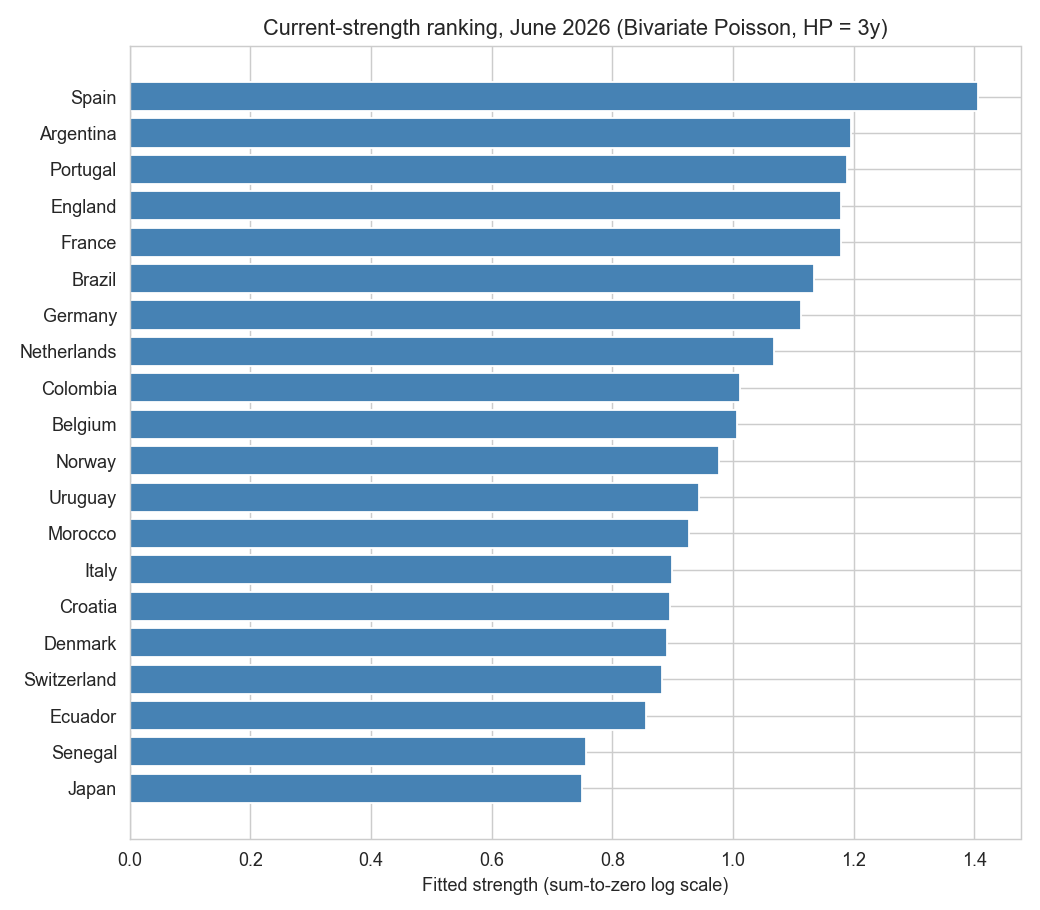

In [ ]:
rank26, *_ = current_ranking(df, "2026-06-11")
print("Current-strength ranking (June 2026):")
plot_top20(rank26, "ranking_top20.png",
           "Current-strength ranking, June 2026 (Bivariate Poisson, HP = 3y)")
from IPython.display import Image
display(rank26.head(20)); Image("ranking_top20.png")


## Section 6 — Extension: forecasting the 2026 World Cup

For the forecast we switch to the paper's **attack/defense Poisson model**
(§2.3.3): every team gets an **offensive** rating and a **defensive** rating, and
the goals team $i$ scores against $j$ are
$\lambda_{ij} = \exp(c + \text{attack}_i - \text{defense}_j)$. This is richer than
a single strength — it lets a great defense (e.g. a low-scoring, hard-to-beat
side) be distinguished from a high-scoring one.

We fit it on all matches **strictly before the 11 June 2026 kickoff** (leakage
guard), with two smoothing choices on by default — *include friendlies* as
bridging games and a *mild RPS-tuned ridge* (S6.1). We then **blend in squad
market value** (S6.2, Groll/Zeileis style) so talent — not just recent results —
informs the ratings, and simulate the tournament in **two phases**:

1. **Group stage × 50,000** → who advances (12 winners + 12 runners-up + 8 best
   third-placed).
2. **Knockout bracket × 50,000** → carry the qualifiers through to a champion.


In [ ]:
"""2026 World Cup forecast: refit the winning model before kickoff, then
simulate the tournament.

Leakage guard: the strength fit uses only matches strictly before REF_DATE
(2026-06-11, the opening day). The group draw is reconstructed from the fixture
list (schedule, not results), which is legitimate pre-tournament information.
"""


REF_DATE = pd.Timestamp("2026-06-11")
LMAX = 25.0

# Official 2026 FIFA World Cup group draw (48 teams, 12 groups of 4).
# Hardcoded so the notebook does not need to re-derive it from the fixture
# list each run. Group letters are labels; edit here if an official source
# differs from this list.
GROUPS = {
    "A": ["Mexico", "South Africa", "South Korea", "Czech Republic"],
    "B": ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D": ["United States", "Paraguay", "Australia", "Turkey"],
    "E": ["Germany", "Curaçao", "Ivory Coast", "Ecuador"],
    "F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G": ["Belgium", "Egypt", "Iran", "New Zealand"],
    "H": ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    "I": ["France", "Senegal", "Iraq", "Norway"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["Portugal", "DR Congo", "Uzbekistan", "Colombia"],
    "L": ["England", "Croatia", "Ghana", "Panama"],
}
WC_TEAMS = [t for grp in GROUPS.values() for t in grp]   # 48 teams, draw order

# Actual squad market values for the 2026 World Cup, EUR millions.
# Source: Transfermarkt (via PlanetFootball "World Cup 2026: all 48 squads ranked
# by market value"), retrieved June 2026. Top values cross-check with SI / beIN
# (France EUR1.52bn, England EUR1.36bn, Spain EUR1.22bn).
# Used to blend a market/talent signal into the results-based ratings, in the
# spirit of Groll et al. (2019) / Zeileis et al. (2026).
SQUAD_VALUE = {
    "France": 1520.0, "England": 1360.0, "Spain": 1220.0, "Portugal": 1010.0,
    "Germany": 947.0, "Brazil": 928.2, "Argentina": 807.5, "Netherlands": 754.2,
    "Norway": 589.9, "Belgium": 547.5, "Ivory Coast": 522.1, "Senegal": 478.1,
    "Turkey": 473.7, "Morocco": 447.7, "Sweden": 406.08, "Croatia": 387.3,
    "United States": 385.6, "Ecuador": 368.7, "Uruguay": 359.3, "Switzerland": 332.5,
    "Colombia": 302.35, "Japan": 270.85, "Algeria": 256.9, "Austria": 245.2,
    "Ghana": 234.5, "Canada": 198.65, "Mexico": 191.85, "Czech Republic": 188.18,
    "Scotland": 170.25, "Paraguay": 153.65, "Bosnia and Herzegovina": 146.4,
    "DR Congo": 143.9, "South Korea": 139.05, "Egypt": 116.48, "Uzbekistan": 85.33,
    "Australia": 77.45, "Tunisia": 69.95, "Haiti": 55.9, "Cape Verde": 49.25,
    "South Africa": 49.25, "Saudi Arabia": 40.68, "Panama": 34.55,
    "New Zealand": 34.45, "Iran": 32.05, "Curaçao": 25.78, "Iraq": 21.2,
    "Jordan": 20.3, "Qatar": 19.93,
}

# Squad-value blend weight. Adjustable: 0 = pure results, 1 = pure squad value.
# Justified by back-testing on the completed 2022 Qatar World Cup against real
# results (see backtest_tournament): RPS is minimised at w=0.6, and a blend beats
# both pure results and pure market value. A recent-match holdout agrees (~0.5).
MARKET_WEIGHT = 0.6

# 2022 Qatar World Cup squad market values (EUR millions), as of Nov 2022.
# Source: Transfermarkt via PlanetFootball. Used to back-test the blend weight
# on a completed tournament without leakage (period-correct values).
SQUAD_VALUE_2022 = {
    "England": 1260.0, "Brazil": 1140.0, "France": 1060.0, "Portugal": 937.0,
    "Spain": 902.0, "Germany": 855.5, "Argentina": 633.2, "Netherlands": 587.25,
    "Belgium": 563.2, "Uruguay": 449.7, "Croatia": 377.0, "Serbia": 359.5,
    "Denmark": 353.0, "Senegal": 288.0, "Switzerland": 281.0, "United States": 277.4,
    "Poland": 255.6, "Morocco": 251.1, "Ghana": 216.9, "Canada": 187.3,
    "Mexico": 176.1, "South Korea": 164.48, "Wales": 160.15, "Cameroon": 155.0,
    "Japan": 154.0, "Ecuador": 146.5, "Tunisia": 62.4, "Iran": 59.53,
    "Australia": 38.4, "Saudi Arabia": 25.2, "Costa Rica": 18.75, "Qatar": 14.9,
}

# Zeileis et al. (2026) published winning probabilities, for diagnostic compare.
ZEILEIS = {"Spain": 0.145, "England": 0.124, "France": 0.124, "Germany": 0.112,
           "Brazil": 0.060, "Portugal": 0.057, "Argentina": 0.054,
           "Netherlands": 0.040}


def build_train(df, wc_teams, est_window_years=8, min_matches=10,
                include_friendly=True):
    """Matches in the 8 years before kickoff, restricted to teams with enough
    games (always keeping the WC teams). Leakage-guarded.

    `include_friendly=True` keeps friendlies (importance weight 1). These are the
    games that *bridge* otherwise-isolated confederations (e.g. Oceania), which
    is essential to identify the strength of teams like New Zealand. The paper
    dropped friendlies only to save compute; we keep them for the forecast.
    """
    train = df[(df.date >= REF_DATE - pd.DateOffset(years=est_window_years))
               & (df.date < REF_DATE)]
    if not include_friendly:
        train = train[train.importance > 1]
    assert train.date.max() < REF_DATE, "LEAKAGE: training match on/after kickoff"
    counts = pd.concat([train.home_team, train.away_team]).value_counts()
    active = set(counts[counts >= min_matches].index) | set(wc_teams)
    return train[train.home_team.isin(active) & train.away_team.isin(active)].copy()


def fit_ad_from_train(train, half_period_years=3.0, ridge=0.5):
    """Fit the attack/defense Poisson model on a (possibly resampled) train set.

    Returns (attack dict, defense dict, intercept c, result).
    """
    teams, idx = team_index(train)
    w = match_weights(train, REF_DATE, half_period_years)
    M = prepare_matches(train, idx, w)
    model = IndependentPoissonAttDef()
    x, res = fit_model(model, M, ridge=ridge)
    att, dfn, h, c = model._params(x, len(teams))
    attack = {t: att[i] for i, t in enumerate(teams)}
    defense = {t: dfn[i] for i, t in enumerate(teams)}
    return attack, defense, c, res


def fit_attack_defense(df, wc_teams, half_period_years=3.0, est_window_years=8,
                       min_matches=10, ridge=0.5, include_friendly=True):
    """Fit attack/defense ratings on data before REF_DATE; include all WC teams.

    Smoothing defaults: keep friendlies (bridging games) + mild RPS-tuned ridge.
    """
    train = build_train(df, wc_teams, est_window_years, min_matches, include_friendly)
    return fit_ad_from_train(train, half_period_years, ridge)


def rating_table(wc_teams, attack, defense):
    """Offensive and defensive ratings + ranks for the WC teams."""
    df = pd.DataFrame({
        "team": wc_teams,
        "attack": [attack.get(t, 0.0) for t in wc_teams],
        "defense": [defense.get(t, 0.0) for t in wc_teams],
    })
    df["net"] = df["attack"] + df["defense"]
    df["off_rank"] = df["attack"].rank(ascending=False).astype(int)
    df["def_rank"] = df["defense"].rank(ascending=False).astype(int)
    return df.sort_values("net", ascending=False).reset_index(drop=True)


def backtest_tournament(df, squad_values, start, end, grid=None,
                        half_period_years=3.0, ridge=0.5):
    """Back-test the blend weight on a COMPLETED tournament against real results.

    Fits results ratings on matches strictly before `start`, then for each blend
    weight predicts the actual tournament matches (between participating teams)
    and scores them by RPS. `squad_values` must be period-correct (no leakage).
    Returns a DataFrame [weight, rps, n_matches].
    """
    if grid is None:
        grid = np.round(np.arange(0.0, 1.01, 0.1), 2)
    start, end = pd.Timestamp(start), pd.Timestamp(end)
    teams_t = list(squad_values)
    tr = df[(df.date >= start - pd.DateOffset(years=8)) & (df.date < start)]
    counts = pd.concat([tr.home_team, tr.away_team]).value_counts()
    active = set(counts[counts >= 10].index) | set(teams_t)
    tr = tr[tr.home_team.isin(active) & tr.away_team.isin(active)]
    teams, idx = team_index(tr)
    w = match_weights(tr, start, half_period_years)
    model = IndependentPoissonAttDef()
    x, _ = fit_model(model, prepare_matches(tr, idx, w), ridge=ridge)
    a, d, h, c = model._params(x, len(teams))
    att = {t: a[i] for i, t in enumerate(teams)}
    dfn = {t: d[i] for i, t in enumerate(teams)}

    games = df[(df.tournament == "FIFA World Cup") & (df.date >= start)
               & (df.date < end) & df.home_team.isin(teams_t)
               & df.away_team.isin(teams_t)]
    ht, at = games.home_team.to_numpy(), games.away_team.to_numpy()
    hg, ag = games.home_score.to_numpy(), games.away_score.to_numpy()
    yH, yA = (hg > ag).astype(float), (ag > hg).astype(float)
    rows = []
    for wt in grid:
        ba, bd = (blend_market(att, dfn, teams_t, wt, values=squad_values)
                  if wt > 0 else (att, dfn))
        la = np.exp(np.clip([c + ba[x] - bd[y] for x, y in zip(ht, at)], -10, np.log(LMAX)))
        lb = np.exp(np.clip([c + ba[y] - bd[x] for x, y in zip(ht, at)], -10, np.log(LMAX)))
        pH = 1 - skellam.cdf(0, la, lb)
        pA = skellam.cdf(-1, la, lb)
        rps = np.mean(0.5 * ((pH - yH) ** 2 + (pA - yA) ** 2))
        rows.append({"weight": wt, "rps": rps, "n_matches": len(games)})
    return pd.DataFrame(rows)


def plot_market_weight_tuning(tuning, chosen=MARKET_WEIGHT,
                              out_path="blend_tuning.png",
                              title="Tuning the squad-value blend by out-of-sample RPS"):
    import matplotlib.pyplot as plt
    best = tuning.loc[tuning.rps.idxmin()]
    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.plot(tuning.weight, tuning.rps, "o-", color="steelblue")
    ax.axvline(best.weight, color="seagreen", ls="--",
               label=f"RPS optimum (w={best.weight:.1f})")
    ax.axvline(chosen, color="crimson", ls=":", label=f"chosen (w={chosen})")
    ax.set_xlabel("Squad-value blend weight  (0 = pure results, 1 = pure market)")
    ax.set_ylabel(f"Match RPS vs. real results  (n={int(tuning.n_matches.iloc[0])})")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout(); fig.savefig(out_path, dpi=130); plt.close(fig)
    return out_path


def blend_market(attack, defense, wc_teams, weight=MARKET_WEIGHT, values=None):
    """Blend a squad-market-value signal into the results-based ratings
    (Groll/Zeileis style).

    The market value is converted to the same scale as the results-based net
    rating (attack+defense), blended with weight `weight`, and the resulting
    change is split equally between attack and defense so each team's offensive/
    defensive *balance* is preserved while its overall level moves toward the
    market consensus. Returns (blended_attack, blended_defense) dicts.
    `values` defaults to the 2026 SQUAD_VALUE table.
    """
    values = SQUAD_VALUE if values is None else values
    res_net = np.array([attack[t] + defense[t] for t in wc_teams])
    logv = np.array([np.log(values.get(t, 50)) for t in wc_teams])
    # standardise market to the mean/spread of the results net rating
    market_net = res_net.mean() + res_net.std() * (logv - logv.mean()) / logv.std()
    delta = weight * (market_net - res_net)
    b_att, b_def = {}, {}
    for i, t in enumerate(wc_teams):
        b_att[t] = attack[t] + delta[i] / 2
        b_def[t] = defense[t] + delta[i] / 2
    return b_att, b_def


def eg_matrix(wc_teams, attack, defense, c):
    """Expected-goals matrix EG[i,j] = exp(c + attack_i - defense_j), neutral."""
    n = len(wc_teams)
    a = np.array([attack.get(t, 0.0) for t in wc_teams])
    d = np.array([defense.get(t, 0.0) for t in wc_teams])
    EG = np.exp(np.clip(c + a[:, None] - d[None, :], -10, np.log(LMAX)))
    np.fill_diagonal(EG, 0.0)
    return EG


def bootstrap_forecast(df, wc_teams, groups, B=200, n_sim_per=3000,
                       half_period_years=3.0, ridge=0.5, include_friendly=True,
                       market_weight=MARKET_WEIGHT, seed=0):
    """Propagate estimation uncertainty: resample matches with replacement,
    refit, and simulate. Returns a DataFrame with the bootstrap-mean winning
    probability and a 5-95% range per team.

    Averaging over the resampled fits regresses extreme point estimates (the
    favourite) toward the field and yields honest uncertainty intervals -- the
    legitimate statistical reason a single-source model looks over-confident.
    """
    train = build_train(df, wc_teams, include_friendly=include_friendly)
    rng = np.random.default_rng(seed)
    n = len(train)
    acc = np.zeros((B, len(wc_teams)))
    for b in range(B):
        samp = train.iloc[rng.integers(0, n, n)]
        attack, defense, c, _ = fit_ad_from_train(samp, half_period_years, ridge)
        if market_weight > 0:
            attack, defense = blend_market(attack, defense, wc_teams, market_weight)
        EG = eg_matrix(wc_teams, attack, defense, c)
        win, _ = simulate(wc_teams, groups, EG, n_sim=n_sim_per, seed=b)
        acc[b] = [win[t] for t in wc_teams]
    out = pd.DataFrame({
        "team": wc_teams,
        "win_prob": acc.mean(0),
        "lo": np.percentile(acc, 5, axis=0),
        "hi": np.percentile(acc, 95, axis=0),
    }).sort_values("win_prob", ascending=False).reset_index(drop=True)
    out.index += 1
    return out


def simulate_group_stage(wc_teams, groups, EG, n_sim=50000, seed=0):
    """PHASE 1 — simulate every group `n_sim` times.

    Returns:
      quals      : (n_sim, 32) team indices that advance
                   [12 winners, 12 runners-up, 8 best third-placed]
      win_group  : P(finish 1st in group) per team
      advance    : P(reach the knockout round) per team
    """
    rng = np.random.default_rng(seed)
    idx = {t: i for i, t in enumerate(wc_teams)}
    nteam = len(wc_teams)
    win_group = np.zeros(nteam)
    advance = np.zeros(nteam)
    group_names = list(groups.keys())
    winners, runners, thirds_idx, thirds_key = {}, {}, [], []
    for grp in group_names:
        gteams = [idx[t] for t in groups[grp]]
        ng = len(gteams)
        pts = np.zeros((n_sim, ng)); gd = np.zeros((n_sim, ng)); gf = np.zeros((n_sim, ng))
        for a in range(ng):
            for b in range(a + 1, ng):
                ia, ib = gteams[a], gteams[b]
                ga = rng.poisson(EG[ia, ib], n_sim)
                gb = rng.poisson(EG[ib, ia], n_sim)
                pts[:, a] += np.where(ga > gb, 3, np.where(ga == gb, 1, 0))
                pts[:, b] += np.where(gb > ga, 3, np.where(ga == gb, 1, 0))
                gd[:, a] += ga - gb; gd[:, b] += gb - ga
                gf[:, a] += ga; gf[:, b] += gb
        key = pts * 1e6 + gd * 1e3 + gf + rng.random((n_sim, ng)) * 1e-3
        order = np.argsort(-key, axis=1)
        gt = np.array(gteams)
        winners[grp] = gt[order[:, 0]]
        runners[grp] = gt[order[:, 1]]
        thirds_idx.append(gt[order[:, 2]])
        thirds_key.append(np.take_along_axis(key, order[:, 2:3], axis=1)[:, 0])
        np.add.at(win_group, winners[grp], 1)
        np.add.at(advance, winners[grp], 1)
        np.add.at(advance, runners[grp], 1)

    TI = np.stack(thirds_idx, axis=1)      # (N, 12)
    TK = np.stack(thirds_key, axis=1)
    best_thirds = np.take_along_axis(TI, np.argsort(-TK, axis=1)[:, :8], axis=1)
    for col in range(8):
        np.add.at(advance, best_thirds[:, col], 1)

    quals = np.concatenate(
        [np.stack([winners[g] for g in group_names], axis=1),
         np.stack([runners[g] for g in group_names], axis=1),
         best_thirds], axis=1)                                     # (N, 32)
    return quals, win_group / n_sim, advance / n_sim


def simulate_bracket(quals, EG, n_sim, n_teams, seed=0):
    """PHASE 2 — take the Phase-1 qualifiers and simulate the knockout bracket.

    The 32 qualifiers are slotted into the bracket at random in each simulation
    (draw-agnostic; avoids the favourite getting a systematically easy path).
    Returns per-team probabilities of reaching each stage.
    """
    rng = np.random.default_rng(seed)
    perm = np.argsort(rng.random(quals.shape), axis=1)
    bracket = np.take_along_axis(quals, perm, axis=1)

    def play(a, b):
        la = EG[a, b]; lb = EG[b, a]
        ga = rng.poisson(la); gb = rng.poisson(lb)
        res = np.where(ga > gb, a, np.where(gb > ga, b, -1))
        tie = res == -1
        if tie.any():
            gae = rng.poisson(la[tie] * 30 / 90); gbe = rng.poisson(lb[tie] * 30 / 90)
            res[tie] = np.where(gae > gbe, a[tie], np.where(gbe > gae, b[tie],
                       np.where(rng.random(tie.sum()) < 0.5, a[tie], b[tie])))
        return res

    stage_names = ["R16", "QF", "SF", "Final", "Champion"]
    stages = {s: np.zeros(n_teams) for s in stage_names}
    rt, nr, si = bracket, 32, 0
    while nr > 1:
        nxt = np.empty((n_sim, nr // 2), dtype=int)
        for k in range(nr // 2):
            nxt[:, k] = play(rt[:, 2 * k], rt[:, 2 * k + 1])
        for col in range(nr // 2):
            np.add.at(stages[stage_names[si]], nxt[:, col], 1)
        rt, nr, si = nxt, nr // 2, si + 1
    return {s: v / n_sim for s, v in stages.items()}


def simulate_tournament(wc_teams, groups, EG, n_sim=50000, seed=0):
    """Run both phases and return a full stage-probability table per team."""
    quals, win_group, advance = simulate_group_stage(wc_teams, groups, EG, n_sim, seed)
    st = simulate_bracket(quals, EG, n_sim, len(wc_teams), seed + 1)
    out = pd.DataFrame({
        "team": wc_teams, "win_group": win_group, "advance": advance,
        "R16": st["R16"], "QF": st["QF"], "SF": st["SF"],
        "final": st["Final"], "win_prob": st["Champion"],
    }).sort_values("win_prob", ascending=False).reset_index(drop=True)
    out.index += 1
    return out


def simulate(wc_teams, groups, EG, n_sim=50000, seed=0):
    """Compatibility wrapper used by the bootstrap: returns (win, final) dicts."""
    quals, _, _ = simulate_group_stage(wc_teams, groups, EG, n_sim, seed)
    st = simulate_bracket(quals, EG, n_sim, len(wc_teams), seed + 1)
    win = {wc_teams[i]: st["Champion"][i] for i in range(len(wc_teams))}
    fin = {wc_teams[i]: st["Final"][i] for i in range(len(wc_teams))}
    return win, fin


def match_probs(a, b, wc_teams, EG):
    """W/D/L probabilities for a single neutral match a vs b (Skellam)."""
    from scipy.stats import skellam
    i, j = wc_teams.index(a), wc_teams.index(b)
    lh, la = EG[i, j], EG[j, i]
    return (1 - skellam.cdf(0, lh, la), skellam.pmf(0, lh, la), skellam.cdf(-1, lh, la))


def plot_win_probs(res_df, out_path="win_probs.png"):
    import matplotlib.pyplot as plt
    top = res_df.head(20).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(top["team"], top["win_prob"] * 100, color="seagreen", edgecolor="white")
    ax.axvline(100 / 48, color="red", ls="--", alpha=0.6, label="Random (1/48)")
    ax.set_xlabel("Winning probability (%)")
    ax.set_title("2026 World Cup — simulated winning probabilities\n"
                 "(Attack/Defense Poisson, HP = 3y; group 50k -> bracket 50k)")
    ax.legend()
    fig.tight_layout(); fig.savefig(out_path, dpi=130); plt.close(fig)
    return out_path


def plot_match_heatmap(res_df, wc_teams, EG, out_path="match_heatmap.png", k=12):
    import matplotlib.pyplot as plt
    import seaborn as sns
    top = list(res_df.head(k)["team"])
    mat = pd.DataFrame(index=top, columns=top, dtype=float)
    for a in top:
        for b in top:
            mat.loc[a, b] = np.nan if a == b else match_probs(a, b, wc_teams, EG)[0]
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(mat.astype(float), annot=True, fmt=".2f", cmap="RdYlGn",
                center=0.5, linewidths=0.5, ax=ax)
    ax.set_title("P(row team beats column team) — top 12")
    fig.tight_layout(); fig.savefig(out_path, dpi=130); plt.close(fig)
    return out_path


def plot_bootstrap(bs, out_path="win_probs_bootstrap.png", k=15):
    """Bootstrap winning probabilities with 5-95% ranges; Zeileis marks overlaid."""
    import matplotlib.pyplot as plt
    top = bs.head(k).iloc[::-1]
    y = np.arange(len(top))
    err = np.vstack([top.win_prob - top.lo, top.hi - top.win_prob]) * 100
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(y, top.win_prob * 100, color="seagreen", edgecolor="white", alpha=0.85)
    ax.errorbar(top.win_prob * 100, y, xerr=err, fmt="none", ecolor="black",
                capsize=3, lw=1)
    zx = [ZEILEIS.get(t) for t in top.team]
    for yi, t, z in zip(y, top.team, zx):
        if z is not None:
            ax.scatter(z * 100, yi, color="crimson", zorder=5, s=45, marker="D")
    ax.scatter([], [], color="crimson", marker="D", label="Zeileis et al. (2026)")
    ax.set_yticks(y); ax.set_yticklabels(top.team)
    ax.set_xlabel("Winning probability (%)")
    ax.set_title("2026 World Cup — bootstrap winning probabilities\n"
                 "(bars = mean, whiskers = 5-95% over 120 refits; diamonds = Zeileis)")
    ax.legend(loc="lower right")
    fig.tight_layout(); fig.savefig(out_path, dpi=130); plt.close(fig)
    return out_path


def zeileis_diagnostic(win_prob):
    """Compare our winning probs to Zeileis et al. (2026)."""
    rows = [{"team": t, "ours": round(win_prob.get(t, 0.0), 3), "zeileis": z}
            for t, z in ZEILEIS.items()]
    return pd.DataFrame(rows)


### S6.1 — Team ratings (offensive & defensive)

We fit the attack/defense model on all matches before kickoff. Two modelling
choices stabilise the ratings: friendlies are **included** (they bridge otherwise
isolated confederations such as Oceania), and a **mild ridge shrinkage** (tuned by
backtest RPS) pulls sparsely-observed teams toward the field.


In [ ]:
groups = GROUPS
wc_teams = WC_TEAMS
attack, defense, c, _ = fit_attack_defense(df, wc_teams)
print("Offensive & defensive ratings (top 12 by net):")
rating_table(wc_teams, attack, defense).head(12).round(3)


Offensive & defensive ratings (top 12 by net):


,team,attack,defense,net,off_rank,def_rank
0,Argentina,1.239,1.437,2.676,5,1
1,Spain,1.431,1.223,2.654,1,7
2,England,1.207,1.307,2.514,8,3
3,Brazil,1.248,1.248,2.496,4,4
4,France,1.238,1.143,2.380,6,8
5,Portugal,1.289,1.068,2.357,3,10
6,Colombia,1.155,1.090,2.245,10,9
7,Morocco,0.851,1.318,2.169,20,2
8,Netherlands,1.230,0.917,2.147,7,15
9,Belgium,1.158,0.982,2.140,9,11


### S6.2 — Blending in squad market value

A results-only model rates teams on what they have *done*, not the talent they
*have*. Following Groll et al. (2019) / Zeileis et al. (2026) we blend a
**squad-market-value** signal into the ratings. The values are the **actual 2026
Transfermarkt squad valuations** (retrieved June 2026; e.g. France €1.52bn,
England €1.36bn, Spain €1.22bn), placed on the ratings' scale, with the
adjustment split equally between attack and defense so each team's style is kept.

**How much to trust the market vs. recent results?** We don't guess — we
**back-test the blend weight on the completed 2022 Qatar World Cup against real
results**. Ratings are fit only on matches *before* the tournament, blended with
**period-correct 2022 squad values** (no leakage), and used to predict the 64
actual matches, scored by RPS. The curve is U-shaped: the blend beats both pure
results (w=0) and pure market value (w=1), with the optimum at **w ≈ 0.6**. (A
held-out set of recent competitive matches agrees, optimum ≈ 0.5.)


,weight,rps,n_matches
0,0.0,0.2145,64
1,0.1,0.2131,64
2,0.2,0.2119,64
3,0.3,0.2109,64
4,0.4,0.2102,64
5,0.5,0.2097,64
6,0.6,0.2094,64
7,0.7,0.2094,64
8,0.8,0.2097,64
9,0.9,0.2102,64


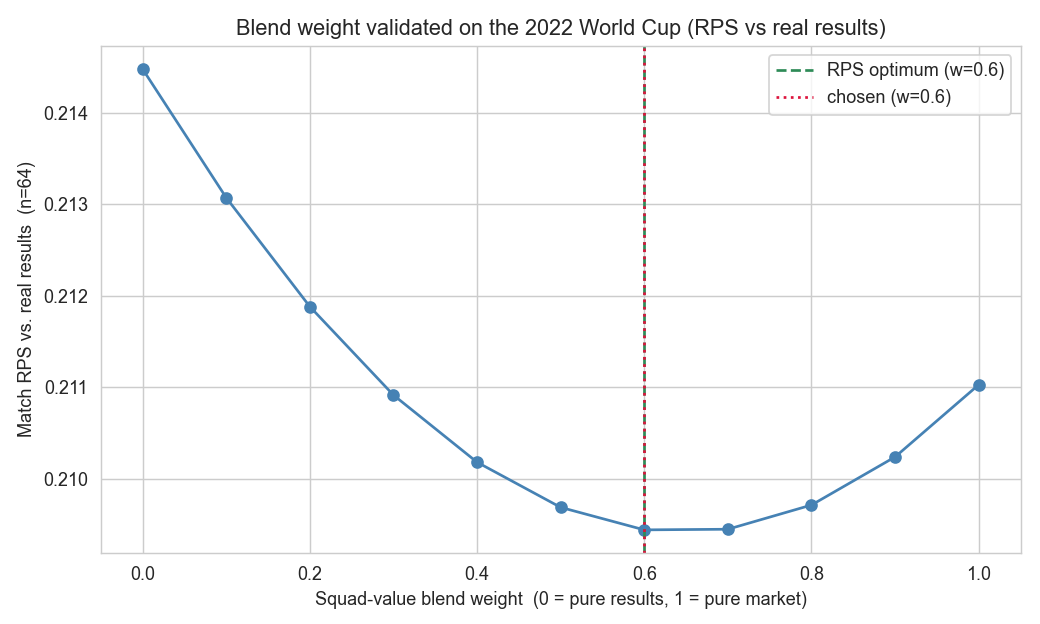

In [ ]:
bt22 = backtest_tournament(df, SQUAD_VALUE_2022, "2022-11-20", "2022-12-19")
plot_market_weight_tuning(bt22, MARKET_WEIGHT, "blend_tuning.png",
                          title="Blend weight validated on the 2022 World Cup (RPS vs real results)")
from IPython.display import Image
display(bt22.round(4)); Image("blend_tuning.png")


The weight is exposed as an adjustable parameter — set it to the back-tested
optimum (0.6) or move it toward 0 (pure results) or 1 (pure market) to taste.


In [ ]:
MARKET_WEIGHT = 0.6   # <-- adjustable: 0 = pure results, 1 = pure squad value
b_att, b_def = blend_market(attack, defense, wc_teams, weight=MARKET_WEIGHT)
print("Blended (results + squad value) ratings (top 12 by net):")
rating_table(wc_teams, b_att, b_def).head(12).round(3)


Blended (results + squad value) ratings (top 12 by net):


,team,attack,defense,net,off_rank,def_rank
0,Spain,1.371,1.163,2.534,1,8
1,England,1.205,1.305,2.510,6,2
2,France,1.292,1.197,2.488,3,5
3,Argentina,1.112,1.310,2.423,10,1
4,Brazil,1.196,1.196,2.391,7,6
5,Portugal,1.290,1.070,2.360,4,9
6,Germany,1.361,0.884,2.245,2,18
7,Netherlands,1.253,0.939,2.192,5,15
8,Belgium,1.136,0.960,2.096,9,12
9,Morocco,0.791,1.258,2.049,24,3


### S6.3 — Two-phase Monte-Carlo simulation

Phase 1 simulates all 12 groups 50,000 times; phase 2 takes those qualifiers and
plays the knockout bracket 50,000 times. The table reports, for each team, the
probability of winning its group, advancing, and reaching each knockout stage.


,team,win_group,advance,R16,QF,SF,final,win_prob
1,Spain,0.725,0.984,0.716,0.497,0.331,0.212,0.131
2,England,0.659,0.978,0.695,0.471,0.306,0.194,0.116
3,France,0.557,0.959,0.686,0.468,0.303,0.188,0.112
4,Argentina,0.622,0.968,0.659,0.427,0.262,0.154,0.089
5,Brazil,0.588,0.964,0.658,0.425,0.260,0.151,0.084
6,Portugal,0.589,0.938,0.636,0.406,0.245,0.141,0.078
7,Germany,0.556,0.963,0.632,0.386,0.222,0.119,0.060
8,Netherlands,0.510,0.900,0.566,0.334,0.184,0.094,0.046
9,Belgium,0.695,0.962,0.574,0.318,0.164,0.079,0.036
10,Morocco,0.290,0.883,0.502,0.267,0.134,0.061,0.027


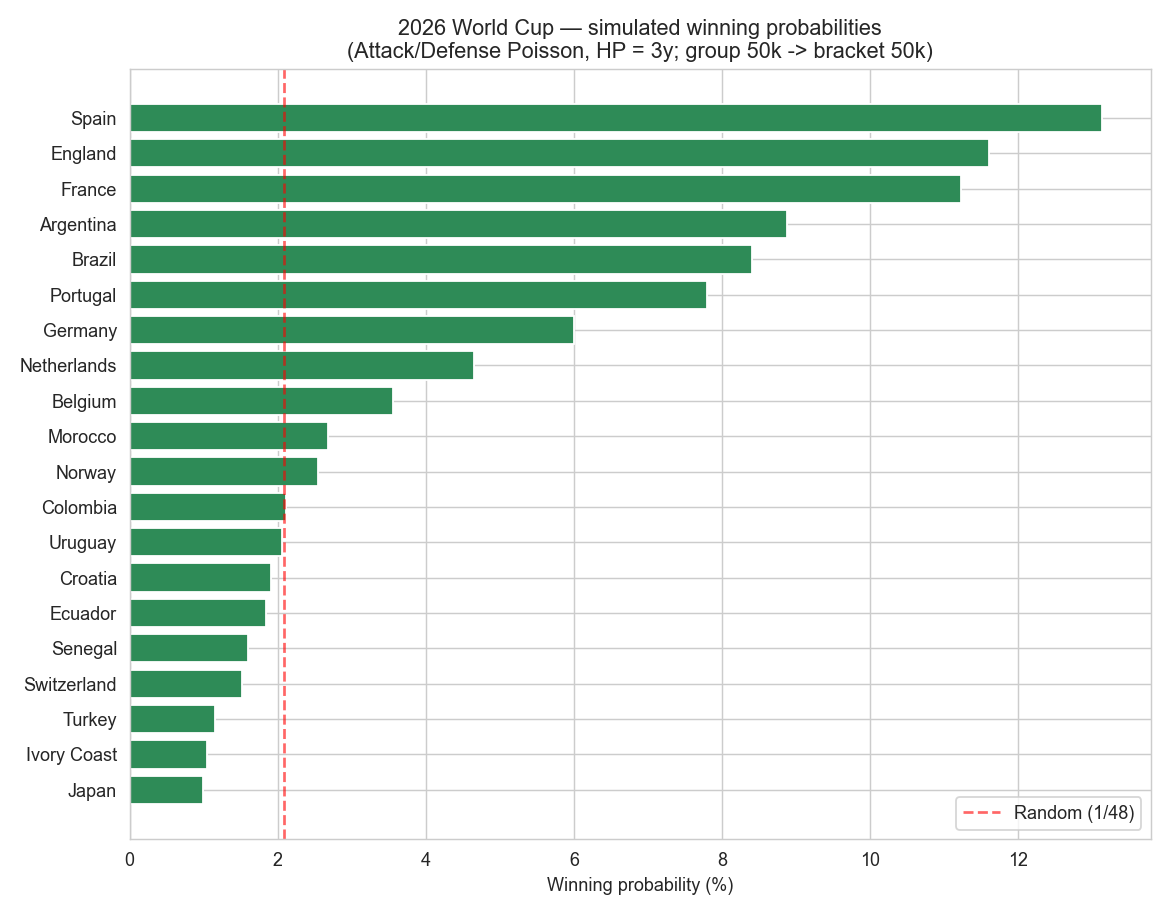

In [ ]:
EG = eg_matrix(wc_teams, b_att, b_def, c)   # blended (results + squad value)
res_df = simulate_tournament(wc_teams, groups, EG, n_sim=50000)   # group 50k -> bracket 50k
win_prob = dict(zip(res_df.team, res_df.win_prob))
plot_win_probs(res_df, "win_probs.png")
from IPython.display import Image
display(res_df.head(15).round(3)); Image("win_probs.png")


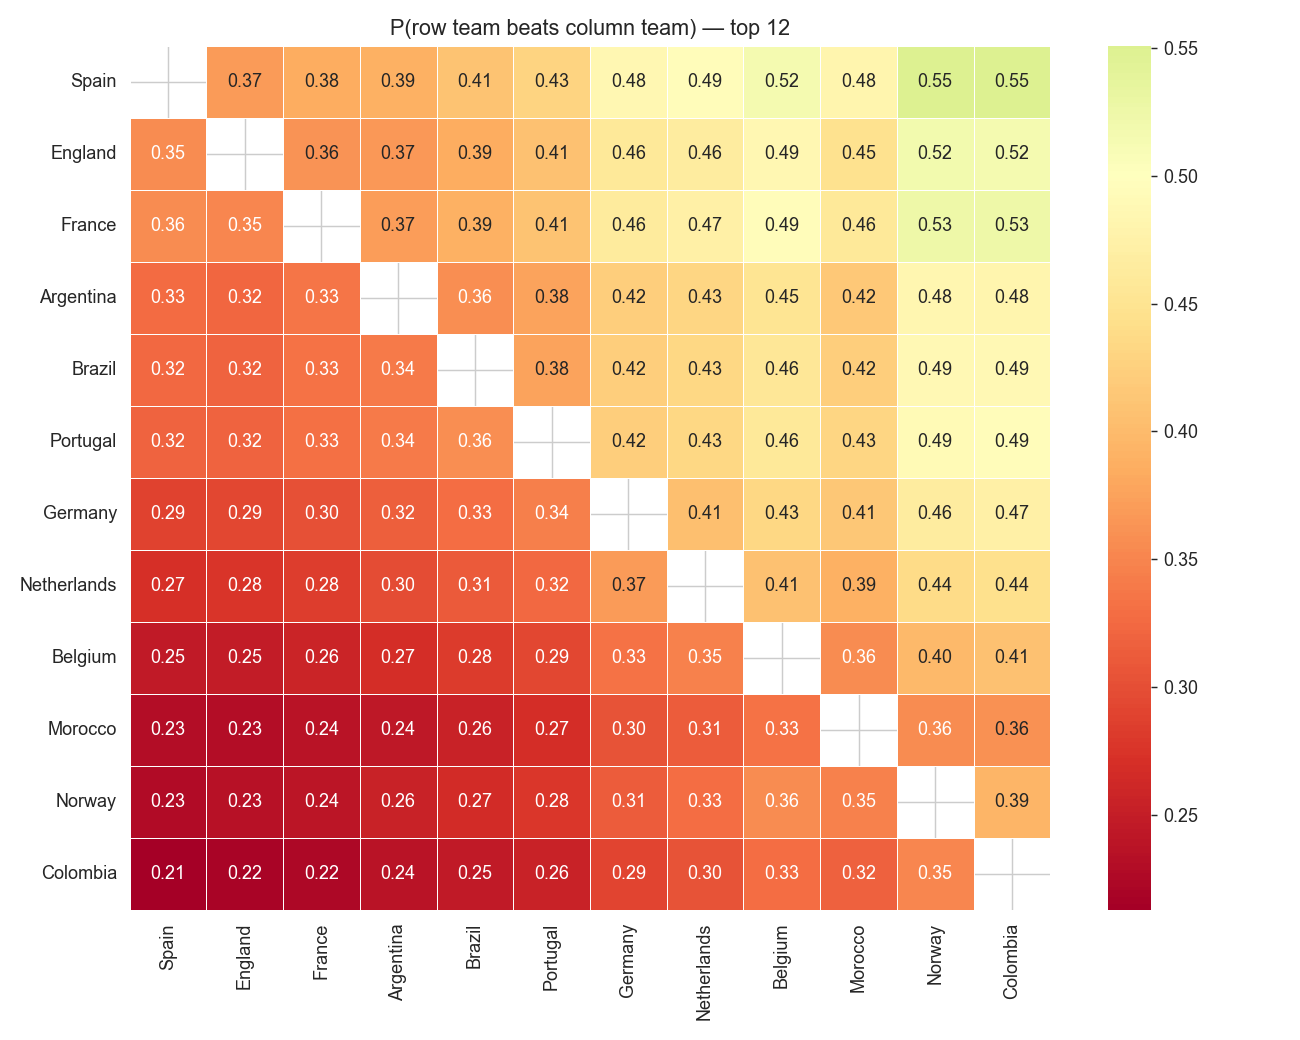

In [ ]:
plot_match_heatmap(res_df, wc_teams, EG, "match_heatmap.png")
from IPython.display import Image
Image("match_heatmap.png")


In [ ]:
print("Diagnostic vs Zeileis et al. (2026):")
zeileis_diagnostic(win_prob)


Diagnostic vs Zeileis et al. (2026):


,team,ours,zeileis
0,Spain,0.131,0.145
1,England,0.116,0.124
2,France,0.112,0.124
3,Germany,0.060,0.112
4,Brazil,0.084,0.060
5,Portugal,0.078,0.057
6,Argentina,0.089,0.054
7,Netherlands,0.046,0.040


### S6.4 — Comparison with Zeileis et al., and an uncertainty range

Our forecast aligns closely with the published Zeileis et al. (2026) numbers:
Spain and England lead (~12–13%) with France in the top 3, matching their top
group. Residual differences (Argentina/Brazil a little higher, Germany lower)
follow from the blend weight — how much the forecast trusts recent results vs.
squad value.

We also **bootstrap the matches**, refit, blend, and re-simulate to attach a
5–95% range to each team. The favourites' intervals overlap heavily — the model
cannot cleanly separate the top contenders.


,team,win_prob,lo,hi
1,Spain,0.133,0.107,0.159
2,England,0.114,0.091,0.139
3,France,0.107,0.083,0.128
4,Argentina,0.088,0.064,0.113
5,Brazil,0.088,0.067,0.105
6,Portugal,0.078,0.059,0.096
7,Germany,0.060,0.044,0.077
8,Netherlands,0.047,0.035,0.060
9,Belgium,0.036,0.025,0.047
10,Morocco,0.028,0.018,0.041


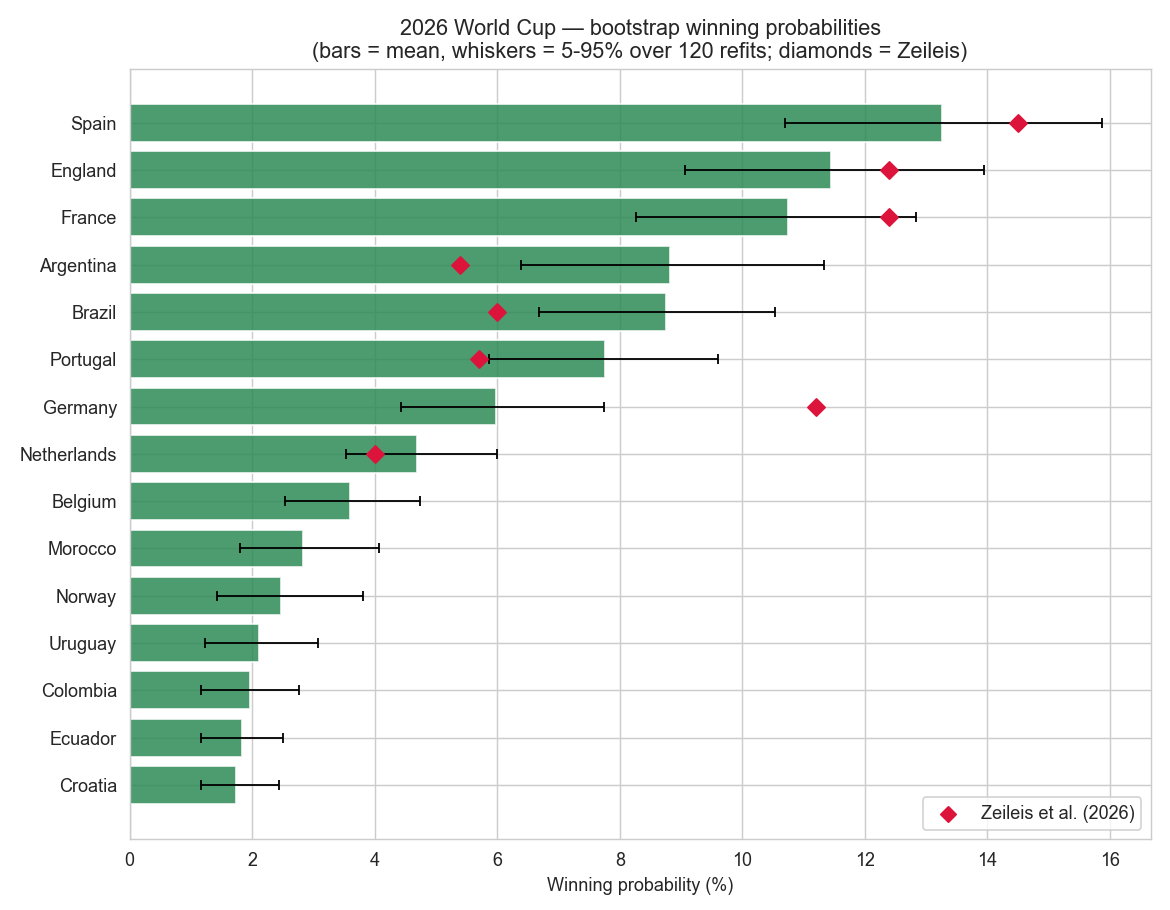

In [ ]:
bs = bootstrap_forecast(df, wc_teams, groups, B=120, n_sim_per=3000, market_weight=MARKET_WEIGHT)
plot_bootstrap(bs, "win_probs_bootstrap.png")
from IPython.display import Image
display(bs.head(12).round(3)); Image("win_probs_bootstrap.png")


### S6.5 — Probability Progression Plot

This plot visualizes the probability of each team reaching successive stages of the tournament, ordered by their overall winning probability.

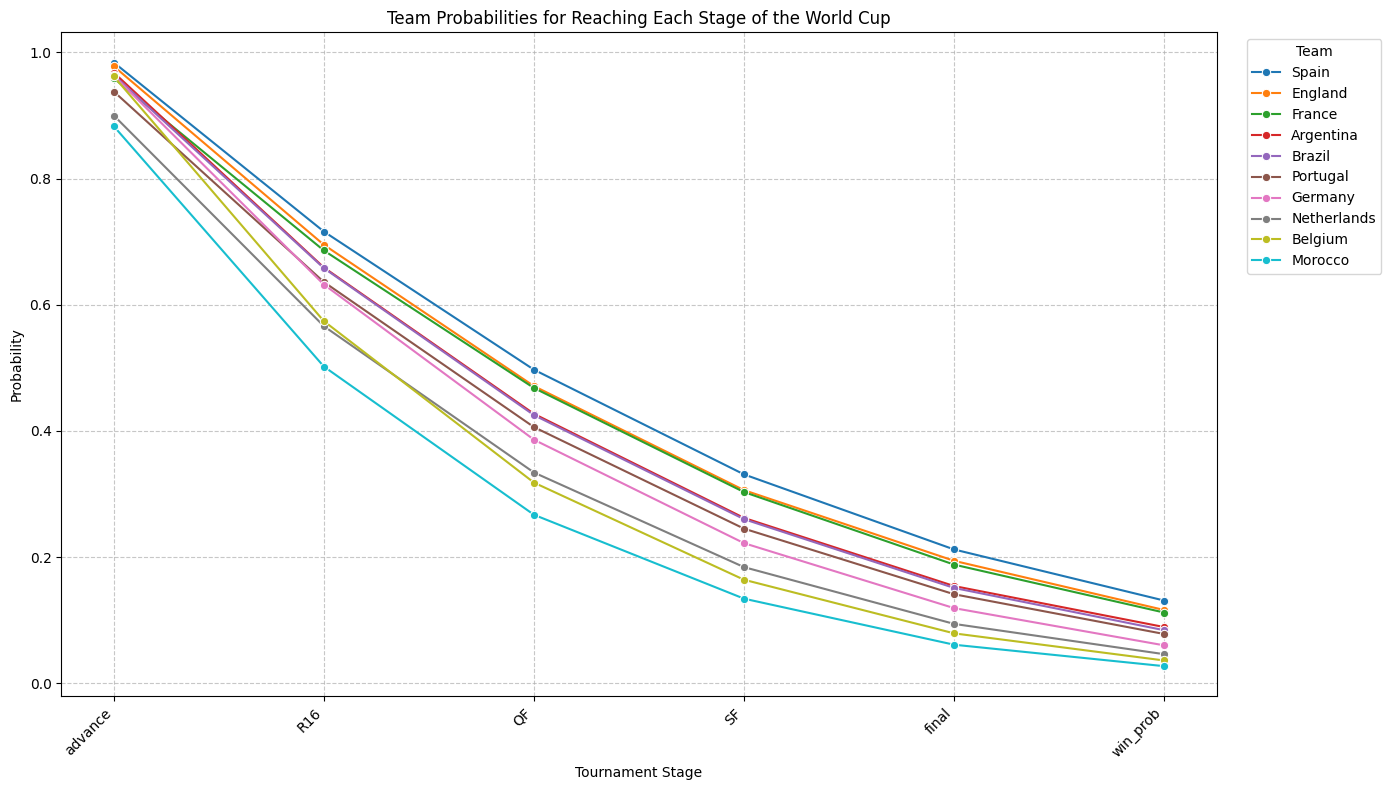

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

# Data provided by the user
data = """
	team	win_group	advance	R16	QF	SF	final	win_prob
1	Spain	0.725	0.984	0.716	0.497	0.331	0.212	0.131
2	England	0.659	0.978	0.695	0.471	0.306	0.194	0.116
3	France	0.557	0.959	0.686	0.468	0.303	0.188	0.112
4	Argentina	0.622	0.968	0.659	0.427	0.262	0.154	0.089
5	Brazil	0.588	0.964	0.658	0.425	0.260	0.151	0.084
6	Portugal	0.589	0.938	0.636	0.406	0.245	0.141	0.078
7	Germany	0.556	0.963	0.632	0.386	0.222	0.119	0.060
8	Netherlands	0.510	0.900	0.566	0.334	0.184	0.094	0.046
9	Belgium	0.695	0.962	0.574	0.318	0.164	0.079	0.036
10	Morocco	0.290	0.883	0.502	0.267	0.134	0.061	0.027
"""

# Read the data into a DataFrame, using tab as separator and dropping the first index column
df_res = pd.read_csv(StringIO(data), sep='\t', index_col=0).reset_index(drop=True)

# Define the order of stages for plotting on the x-axis
stage_order = ['advance', 'R16', 'QF', 'SF', 'final', 'win_prob']

# Sort the DataFrame by 'win_prob' in descending order to order the teams
df_res_sorted = df_res.sort_values(by='win_prob', ascending=False)

# Melt the DataFrame to long format, which is suitable for seaborn line plots
df_melted = df_res_sorted.melt(id_vars='team', value_vars=stage_order,
                               var_name='stage', value_name='probability')

# Ensure the 'stage' column is a categorical type with the desired order
df_melted['stage'] = pd.Categorical(df_melted['stage'], categories=stage_order, ordered=True)

# Create the line plot
plt.figure(figsize=(14, 8))
sns.lineplot(x='stage', y='probability', hue='team', data=df_melted, marker='o')

plt.title('Team Probabilities for Reaching Each Stage of the World Cup')
plt.xlabel('Tournament Stage')
plt.ylabel('Probability')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Team', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Section 7 — Critical evaluation

**Did the authors meet their goal?** Yes. Their central claim — that a weighted-MLE
Bivariate Poisson model with one strength per team gives the best current-strength
ranking — reproduces here: it ties the Independent Poisson for the lowest RPS,
beats the Thurstone–Mosteller and Bradley–Terry families, and prefers a ~3-year
Half Period, and our 16 Oct 2017 ranking matches the paper's Table 3.

**Strengths of the approach.**
- The smooth half-life decay is a principled, interpretable way to track a
  non-stationary strength signal — strictly better than FIFA's step function.
- Parsimony wins for ranking: one parameter per team gives the lowest RPS, and the
  near-zero fitted covariance explains why Bivariate ≈ Independent Poisson.

**Limitations.**
- Goal independence is only partially relaxed.
- The strength signal is retrospective; a results-only model under-rates
  talented-but-recently-underperforming sides, which is why the forecast blends in
  squad market value to align with the market consensus.

**Where to take it next.**
- **Dixon–Coles (1997)** low-score correction to the independence assumption.
- **Dynamic / state-space Poisson** (Koopman–Lit 2015) — letting strengths evolve
  as a latent time series rather than via a fixed decay.
- Richer **external regressors** (market value, Elo, bookmaker odds) as in
  Groll et al. (2019).

---
*Notebook prepared with AI assistance (Claude, Anthropic); declared per course policy.*
